# 01 | LangGraph 入门第一步：从开发环境搭建到可视化跑通

LangGraph 是一个用于构建有状态 Agent 的工作流编排框架。

它不负责让模型变得更聪明，而是负责一件更工程化的事：**当 Agent 需要经过多个步骤时，明确控制每一步的执行顺序和状态变化。**

一个简单 Agent 可能只需要：

```text
用户提问 -> 模型调用工具 -> 返回答案
```

但真实业务往往更像这样：

```text
分析任务
 -> 查询多个系统
 -> 根据结果分支
 -> 必要时等待人工审批
 -> 失败后从中断位置恢复
 -> 输出最终报告
```

当流程开始出现分支、循环、暂停和恢复，再把所有逻辑塞进一个 Agent 函数里，代码很快就会从“智能”变成“看不懂”。

LangGraph 的价值，就是把这套流程显式表示成一张图：节点负责执行任务，边负责决定下一步，状态负责在不同节点之间传递数据。流程不再藏在一堆 `if/else` 里，调试和维护都会直观很多。

这个系列会从 State、Node、Edge 开始，逐步进入条件分支、工具循环、记忆、暂停恢复、子图和真实项目。

> **版本基线**：本文及后续实操基于截至 2026 年 6 月 11 日的官方最新稳定版本：`langgraph 1.2.4`、`langgraph-cli 0.4.28`。后续示例以 LangGraph `v1.x` 官方文档为准，不再沿用旧版 `0.x` 教程。

第一篇先不急着画复杂的图。我们从开发环境开始，用官方 CLI 创建一个标准项目，并把本地开发服务真正跑起来。

## 一、先安装 LangGraph CLI

LangGraph 的核心库和 CLI 是两个独立软件包：

- `langgraph`：提供 State、Node、Edge 和图执行能力；
- `langgraph-cli`：负责创建项目、启动本地开发服务和连接 Studio。

本文使用 `uv` 管理工具和项目依赖，并以 **Python 3.11 及以上版本**运行本地开发服务器。

先把 CLI 安装为全局工具，方便在任意目录创建项目。`[inmem]` 会同时安装 `langgraph dev` 所需的轻量级本地运行时，不需要额外启动 Docker。

In [ ]:
# 安装 CLI；如果本机已有旧版，则升级到当前最新兼容版本
uv tool install --upgrade "langgraph-cli[inmem]"

# 验证 CLI 是否安装成功
langgraph --version

当前验证输出：

```text
LangGraph CLI, version 0.4.28
```

全局 CLI 主要用于创建项目。官方模板还会把 CLI 放进项目的开发依赖并写入锁文件，因此后续使用 `uv run langgraph dev` 时，实际运行的是项目锁定的版本。

这里要记住：

```text
Python 能 import langgraph
不代表终端一定存在 langgraph 命令
```

如果出现 `zsh: command not found: langgraph`，通常不是核心库损坏，而是 CLI 还没安装。

## 二、用官方模板创建项目

这里显式选择 `new-langgraph-project-python`，创建一个适合入门的 Python LangGraph 工程。

In [ ]:
# 使用官方 Python 入门模板创建项目
langgraph new langgraph-learning \
  --template new-langgraph-project-python

注意，初始化项目的时候如果省略 `--template`，CLI 会进入交互选择。对第一次学习的人来说，交互菜单看起来很友好，

但一不留神选到 Deep Agent 模板，Hello World 还没看懂，项目先长出了半套生产架构。

## 三、认识 LangGraph 项目结构

创建后的核心结构大致如下：

```text
.
└── langgraph-learning                 # LangGraph 项目根目录
    ├── langgraph.json                 # 应用配置：声明依赖、Graph 入口和环境变量文件
    ├── LICENSE                        # 项目开源许可证
    ├── Makefile                       # 常用测试、检查和格式化命令
    ├── pyproject.toml                 # Python 版本、项目依赖和开发工具配置
    ├── README.md                      # 项目使用说明
    ├── src                            # 业务源代码目录
    │   └── agent                      # 当前 Agent 的 Python 包
    │       ├── __init__.py            # 将目录声明为可导入的 Python 包
    │       └── graph.py               # 定义 State、Node、Edge 和编译后的 Graph
    ├── static                         # 文档或界面使用的静态资源
    │   └── studio_ui.png              # 模板提供的 Studio 界面示意图
    ├── tests                          # 自动化测试目录
    │   ├── conftest.py                # pytest 公共配置与 fixture
    │   ├── integration_tests          # LangSmith 集成测试，通常需要有效的 API Key
    │   │   ├── __init__.py
    │   │   └── test_graph.py          # Graph 集成测试
    │   └── unit_tests                 # 验证局部逻辑和图配置
    │       ├── __init__.py
    │       └── test_configuration.py  # Graph 配置单元测试
    └── uv.lock                        # 锁定实际安装的依赖版本

8 directories, 14 files
```

脚手架的价值不是替你写完业务，而是先给出一套官方约定。我们沿着它跑通，再逐步改造。

这里要明确本系列的项目演进顺序：

```text
第 01～03 篇
 -> 保留官方模板，理解项目、启动链路和 Studio 数据流

第 04 篇开始
 -> 增加模型与工具依赖，把模板改造成订单金额计算助手
```

因此，此时项目里还没有 `calculate_order_total`、`ToolNode` 或 `deepseek-v4-flash`，这是正常的。

## 四、同步依赖并确认实际版本

当前项目的 `pyproject.toml` 已经声明了核心库和开发工具，相关配置如下：

```toml
[project]
name = "agent"
version = "0.0.1"
description = "Starter template for making a new agent LangGraph."
authors = [
    { name = "your name", email = "your email" },
]
readme = "README.md"
license = { text = "MIT" }
requires-python = ">=3.10"
dependencies = [
    "langgraph>=1.0.0",
    "python-dotenv>=1.0.1",
]

[dependency-groups]
dev = [
    "langgraph-cli[inmem]>=0.4.28",
    "pytest>=9.0.3",
]

# 其余构建与工具配置略
```

模板声明 `requires-python = ">=3.10"`，表示核心项目允许 Python 3.10；但当前官方 `langgraph dev` 本地开发服务器要求 Python 3.11 及以上版本，因此本文按 Python 3.11+ 准备环境。

项目已经声明 `langgraph`，因此不需要再执行一次 `pip install langgraph`。

`uv sync` 会读取 `pyproject.toml` 和 `uv.lock`，创建项目环境并安装 LangGraph 核心库、项目 CLI 和其他依赖。

为了让新项目对齐本文的最新版本基线，首次同步时显式升级 `langgraph` 和 `langgraph-cli`，然后分别验证版本。

In [ ]:
cd langgraph-learning

# 安装项目依赖，并将 LangGraph 核心库与项目 CLI 升级到当前兼容的最新版本
uv sync --upgrade-package langgraph --upgrade-package langgraph-cli

# 验证项目实际使用的 LangGraph 核心库版本
uv run python -c "import importlib.metadata as m; print(m.version('langgraph'))"

# 验证项目环境中的 CLI 版本
uv run langgraph --version

# 先运行不访问模型服务的单元测试
uv run pytest tests/unit_tests

本文对应的版本输出应为：

```text
1.2.4
LangGraph CLI, version 0.4.28
```

第一行是项目实际使用的 `langgraph` 核心库版本，第二行是项目环境中的 CLI 版本。不要只看全局 `langgraph --version`，项目真正运行的是 `uv run` 对应的锁定环境。

## 五、启动本地 Agent Server

依赖和测试都正常后，启动本地开发服务器：

In [ ]:
cd langgraph-learning

# 该命令会持续运行；停止服务时按 Ctrl+C
uv run langgraph dev

这里使用 `uv run langgraph dev`，是为了明确使用当前项目锁定的 CLI 和运行环境。

如果直接运行 `langgraph dev`，调用的可能是电脑上的全局 CLI。短期看都能跑，等到团队协作或者几个月后重开项目，就容易上演“我这里明明没问题”的经典悬疑剧情。

启动成功后，本地服务通常监听：

```text
http://127.0.0.1:2024
```

终端还会给出 LangGraph Studio 链接。此时 Graph 代码仍然运行在本机，Studio 只是浏览器中的调试界面。两者如何连接，后续会单独拆开讲。

## 六、通过 LangGraph Studio 调试 Graph

默认情况下，CLI 会自动打开 `https://smith.langchain.com/` 中的 Studio 页面；如果不希望自动打开浏览器，可以启动时添加 `--no-browser`。

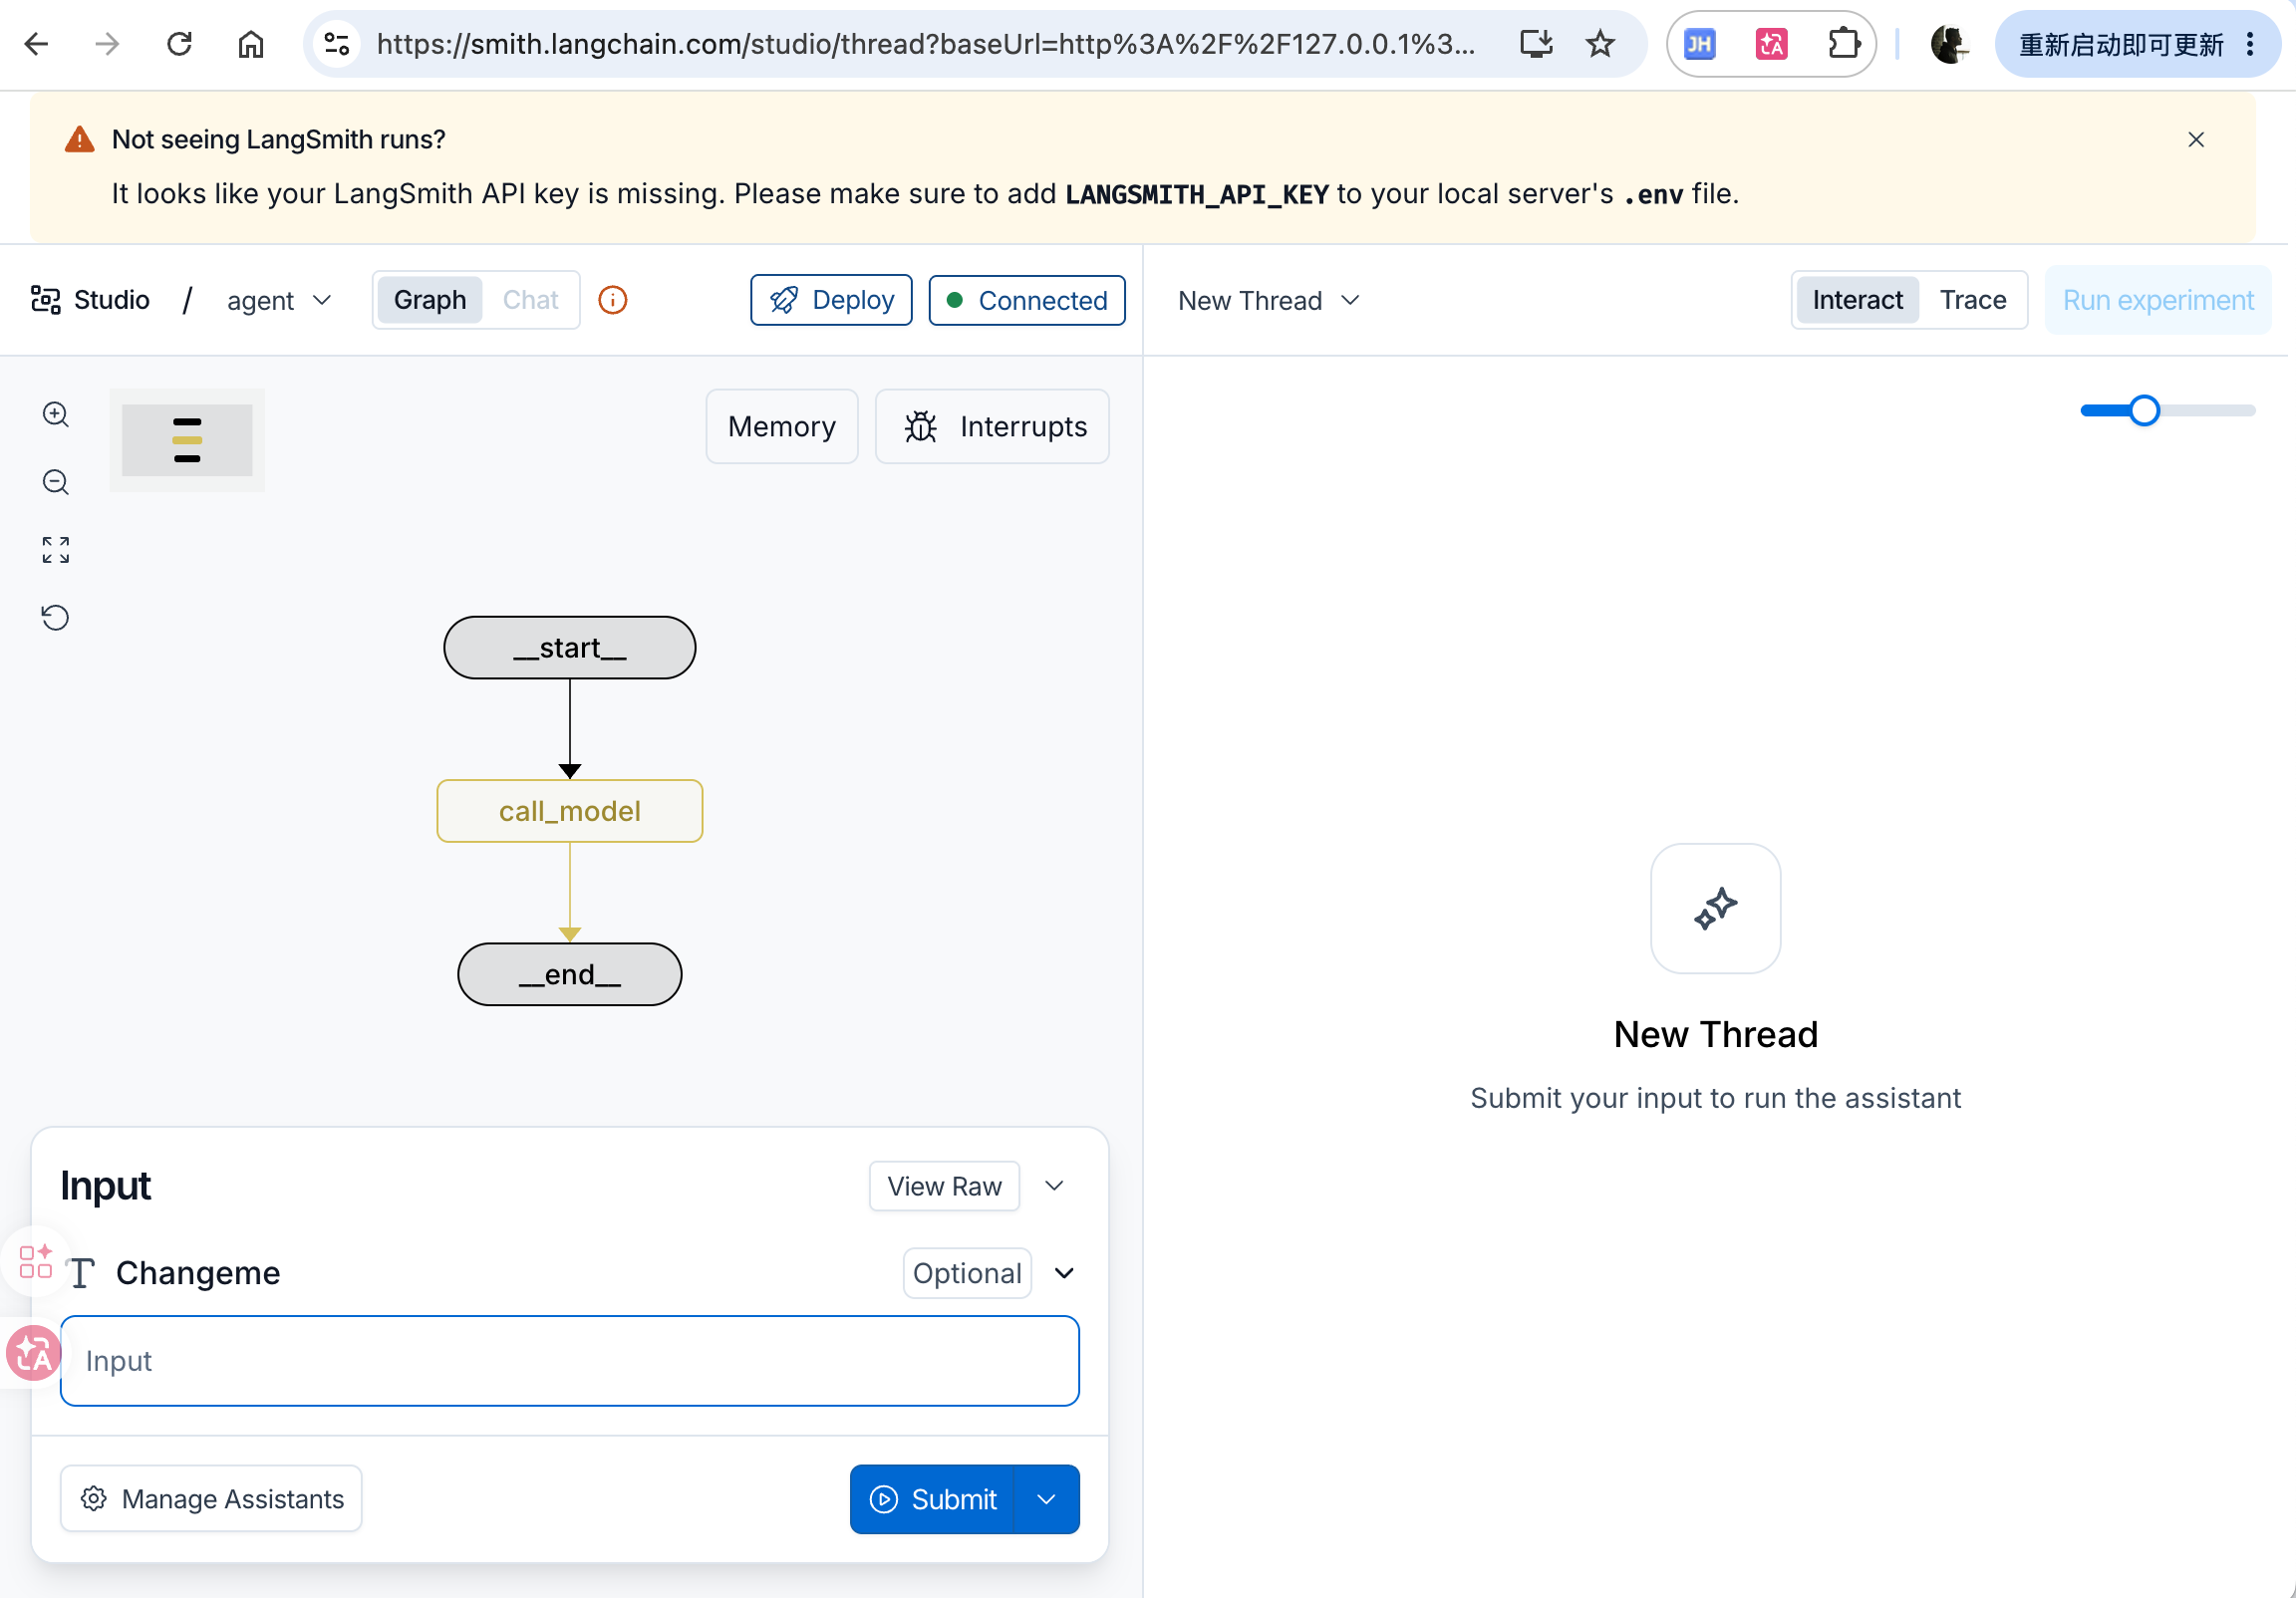

如果浏览器尚未登录 LangSmith，Studio 会跳转到登录或注册页面：

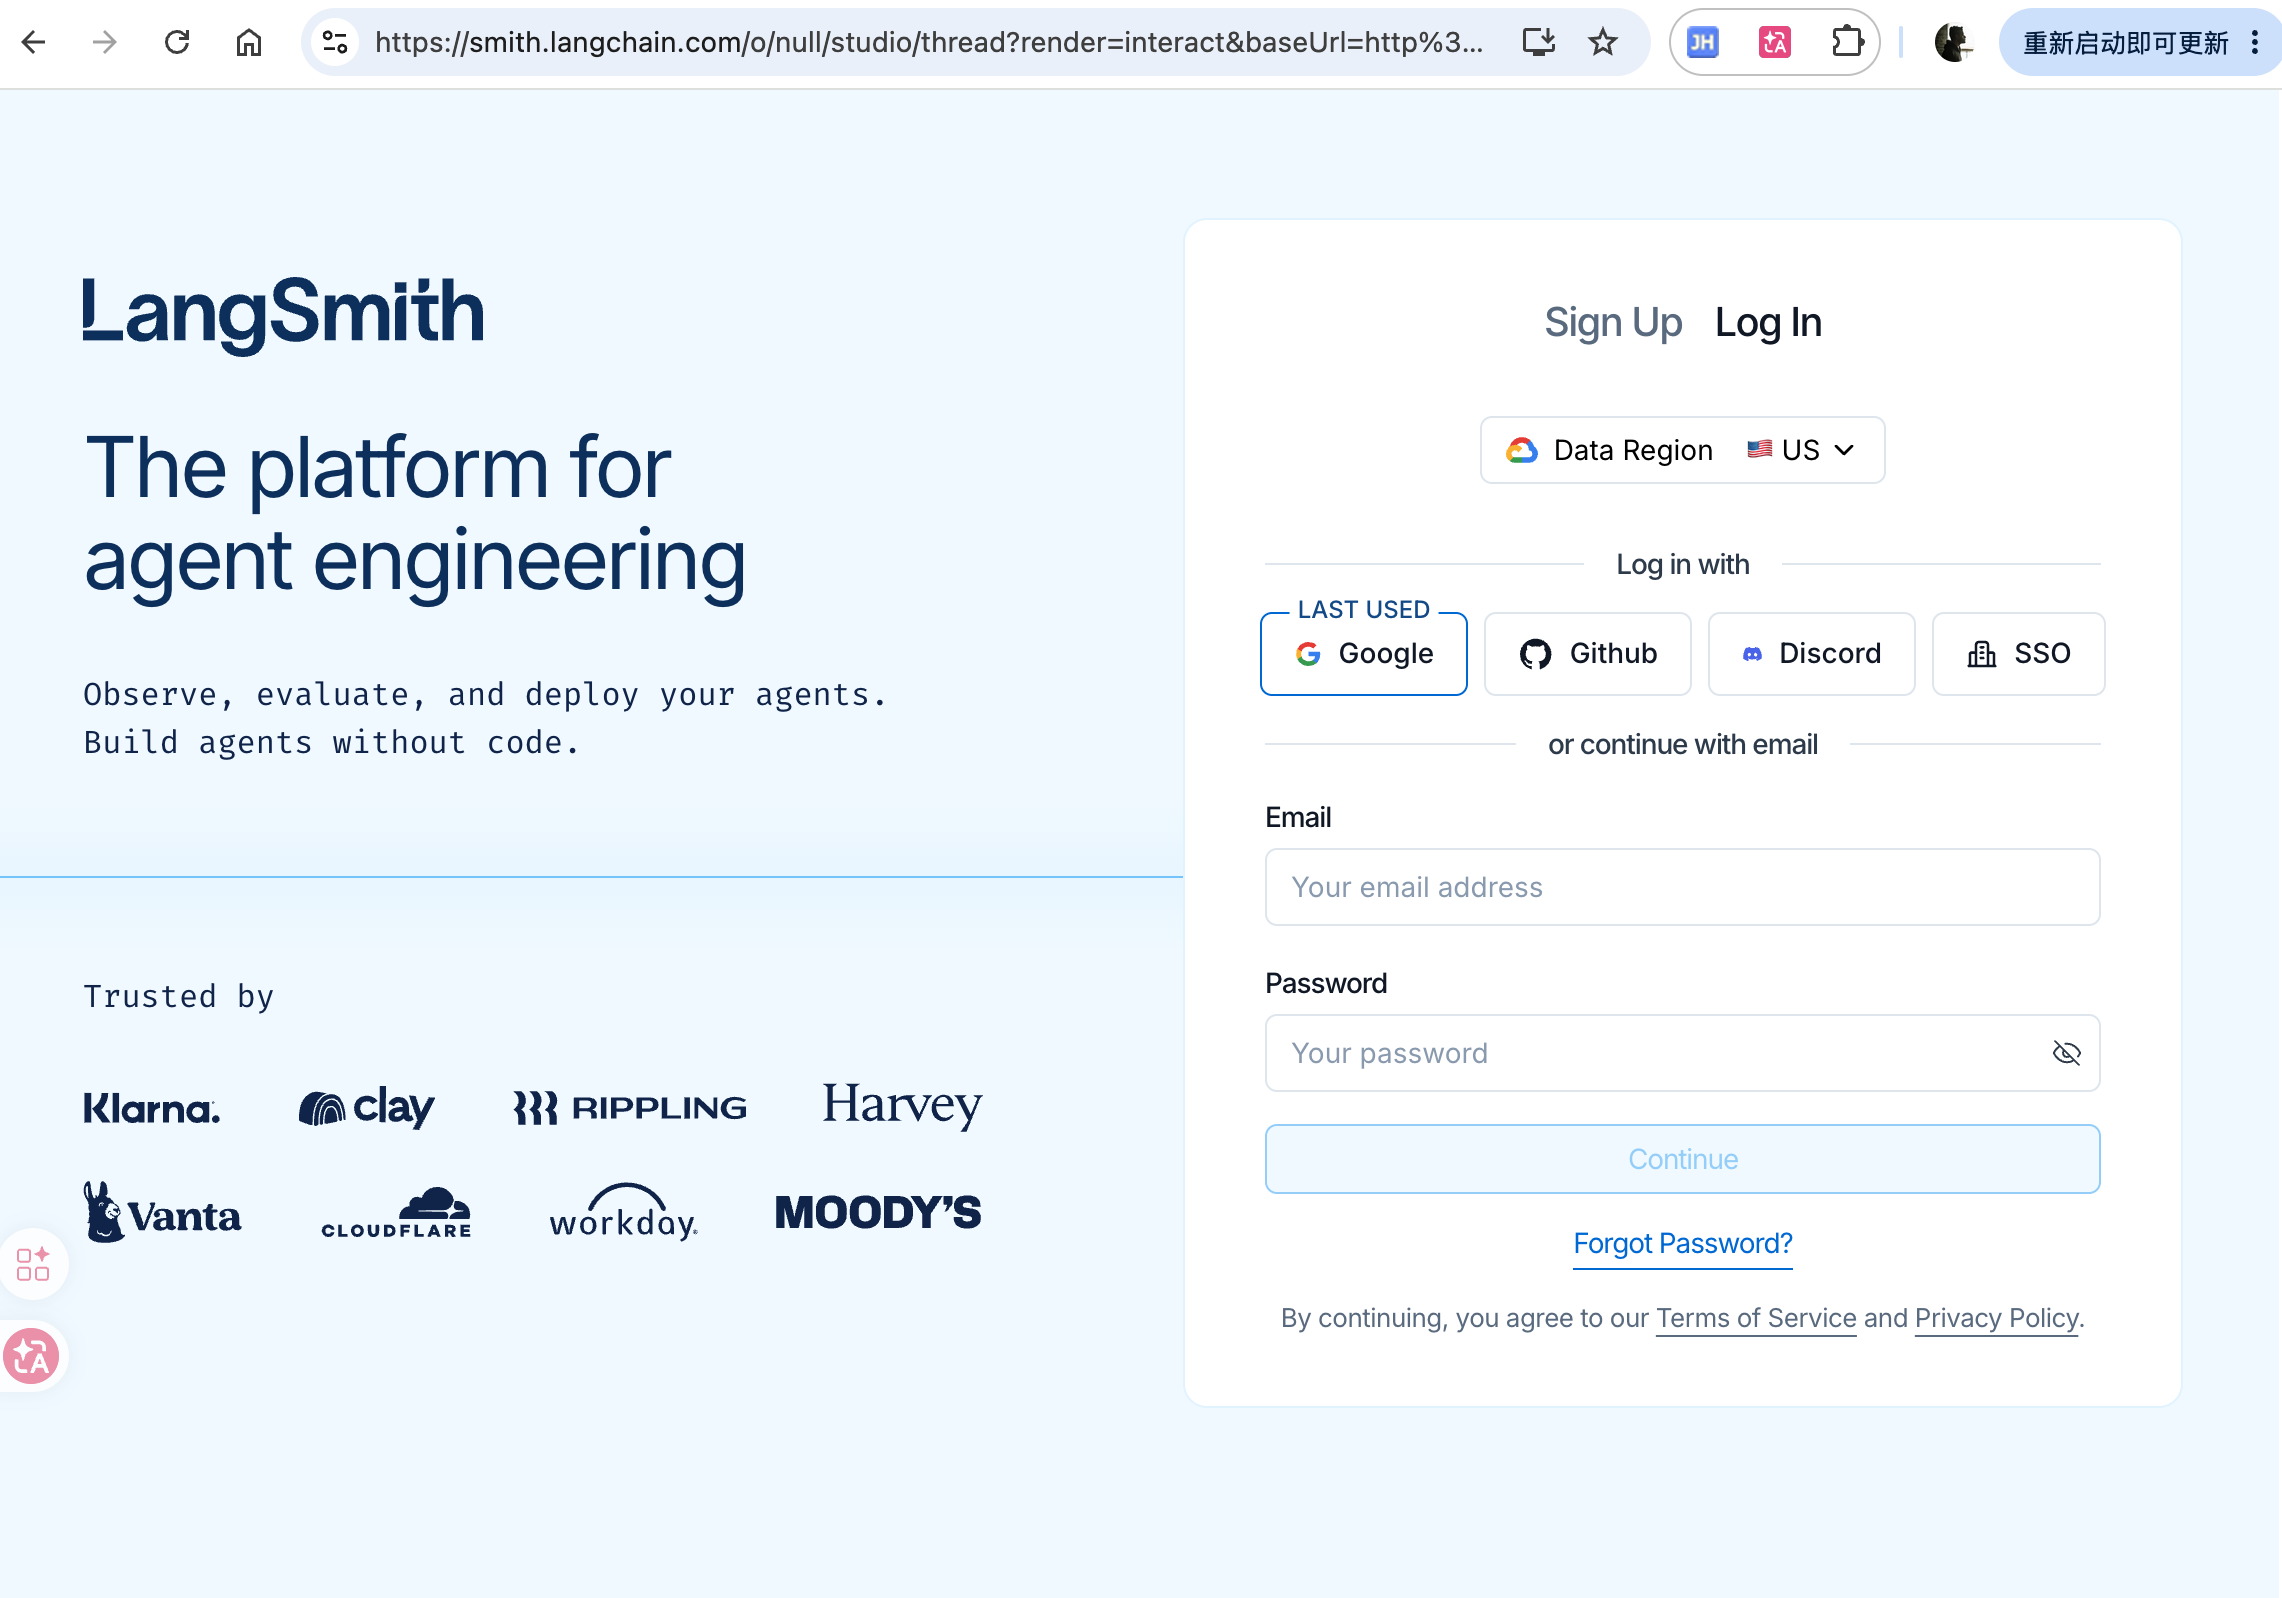

首次使用需要注册或登录，并选择面向开发者的 LangSmith 模式。当前官方文档还将 LangSmith API Key 列为 Studio 的前置条件；创建 Key 后，将它写入项目 `.env`：

```dotenv
# 用于访问 LangSmith Studio
LANGSMITH_API_KEY=你的_LangSmith_API_Key

# 本系列默认不上传运行 Trace
LANGSMITH_TRACING=false
```

账号和 API Key 用于访问 Studio，并不代表 Graph 已经部署到云端。真正执行 Graph 的仍是本机 `127.0.0.1:2024` 服务；只有将 `LANGSMITH_TRACING` 设为 `true` 时，运行 Trace 才会上传。

本文的“跑通”标准是：Agent Server 成功启动、Studio 显示 `Connected`，并且页面能够看到模板 Graph。这里暂不要求调用大模型得到业务回答，因为官方模板还没有被改造成订单助手。

第 04 篇开始接入模型时，会再加入 `DASHSCOPE_BASE_URL` 和 `DASHSCOPE_API_KEY`。Studio、本地 Agent Server、LangSmith Trace 之间的数据流，会在第 03 篇单独说明。

## 七、如果请求模型时报 `socksio` 缺失

如果系统配置了 SOCKS 代理，底层 `httpx` 会尝试通过代理访问模型服务。这时可能出现：

```text
Using SOCKS proxy, but the 'socksio' package is not installed
```

这不是模型问题，而是当前项目缺少 SOCKS 客户端依赖。将支持能力正式写入项目依赖，然后重启服务。

In [ ]:
cd langgraph-learning

# 将 SOCKS 支持写入当前项目依赖
uv add "httpx[socks]"

# 依赖变化后重新启动开发服务器
uv run langgraph dev

## 小结

到这里，我们完成了七件事：

1. 安装 LangGraph CLI；
2. 使用官方模板创建 Python 项目；
3. 认识 LangGraph 项目的核心目录和文件；
4. 通过 `uv sync` 安装锁定依赖并确认实际版本；
5. 使用 `uv run langgraph dev` 启动本地 Agent Server；
6. 登录 LangGraph Studio 并连接本地 Graph；
7. 处理 SOCKS 代理缺少依赖的问题。

环境搭建的目标不是让终端多打印几行绿色文字，而是得到一个后续可以持续修改、测试和调试的标准工程。

第 02 篇继续拆解这个工程：`langgraph dev` 到底如何通过 `langgraph.json` 找到 `graph.py`，又是怎样把一段 Python 代码变成网页中可见的 Graph。